In [1]:
# ==============================================================================
# CELL 1: INSTALL LIBRARY, MOUNT DRIVE, & SETUP DIREKTORI
# ==============================================================================
!pip install kagglehub tf2onnx onnx opencv-python pandas numpy seaborn matplotlib scikit-learn tensorflow tqdm

import os
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import tf2onnx
import onnx
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.2 MB/s eta 0:00:00


In [2]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Setup Direktori Drive (Penyimpanan Permanen) & Lokal (Penyimpanan Cepat)
DRIVE_BASE_DIR = '/content/drive/MyDrive/Skripsi_EcoPlan'
DRIVE_DATASET_DIR = os.path.join(DRIVE_BASE_DIR, 'dataset')
DRIVE_MODEL_DIR = os.path.join(DRIVE_BASE_DIR, 'models')
LOCAL_DATASET_DIR = '/content/dataset_local'

os.makedirs(DRIVE_DATASET_DIR, exist_ok=True)
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
# ==============================================================================
# CELL 2: MANAJEMEN DATASET (DOWNLOAD, COPY KE LOKAL) & SPLIT DATA
# ==============================================================================
# 1. Cek apakah dataset sudah ada di Drive. Jika belum, download via Kagglehub.
if len(os.listdir(DRIVE_DATASET_DIR)) == 0:
    print("\n[INFO] Dataset belum ada di Drive. Mengunduh dari Kaggle...")
    dataset_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

    # Cari folder utama yang berisi sub-folder kelas
    source_dataset = dataset_path
    for root, dirs, files in os.walk(dataset_path):
        if len(dirs) > 2:
            source_dataset = root
            break

    # Copy dari hasil download ke Google Drive agar tersimpan permanen
    print("\n[INFO] Menyalin dataset ke Google Drive...")
    for item in os.listdir(source_dataset):
        s = os.path.join(source_dataset, item)
        d = os.path.join(DRIVE_DATASET_DIR, item)
        if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
else:
    print("\n[INFO] Dataset sudah tersedia di Google Drive.")

# 2. Copy dataset dari Drive ke Lokal Colab untuk mempercepat proses Epoch I/O
if not os.path.exists(LOCAL_DATASET_DIR):
    print("\n[INFO] Menyalin dataset dari Drive ke Lokal Colab (Mempercepat Training)...")
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
else:
    print("\n[INFO] Dataset sudah ada di Lokal Colab.")

# 3. Labeling dan Split Dataset
data = []
for root, dirs, files in os.walk(LOCAL_DATASET_DIR):
    for img_file in files:
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            folder_name = os.path.basename(root)
            data.append({'path': os.path.join(root, img_file), 'label': folder_name})

df_all = pd.DataFrame(data)
num_classes = len(df_all['label'].unique())

print("\n[INFO] Melakukan Pembagian Dataset (80:10:10)...")
train_df, temp_df = train_test_split(df_all, test_size=0.20, stratify=df_all['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"Distribusi Split -> Training: {len(train_df)} | Validation: {len(val_df)} | Testing: {len(test_df)}")


[INFO] Dataset sudah tersedia di Google Drive.

[INFO] Menyalin dataset dari Drive ke Lokal Colab (Mempercepat Training)...

[INFO] Melakukan Pembagian Dataset (80:10:10)...
Distribusi Split -> Training: 29421 | Validation: 3678 | Testing: 3678


In [4]:
# ==============================================================================
# CELL 3: SETUP GENERATOR (AUGMENTASI & NORMALISASI)
# ==============================================================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=res_preprocess, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15, shear_range=0.15,
    zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=res_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='path', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label', target_size=IMG_SIZE,
    batch_size=1, class_mode='categorical', shuffle=False
)

Found 29421 validated image filenames belonging to 10 classes.
Found 3678 validated image filenames belonging to 10 classes.
Found 3678 validated image filenames belonging to 10 classes.


In [5]:
# ==============================================================================
# CELL 4: TRAINING (AUTO-RESUME & SAVE TO DRIVE)
# ==============================================================================
EPOCHS_LIMIT = 50
model_path_base = os.path.join(DRIVE_MODEL_DIR, "resnet50_best.keras")
csv_path = os.path.join(DRIVE_MODEL_DIR, "training_log.csv")

# Setup Callbacks yang langsung menyimpan ke Drive
callbacks_base = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6, monitor='val_loss'),
    ModelCheckpoint(filepath=model_path_base, save_best_only=True, monitor='val_loss', verbose=1),
    CSVLogger(csv_path, append=True)
]

# Cek Auto-Resume
last_epoch = 0
if os.path.exists(csv_path) and os.path.exists(model_path_base):
    try:
        df_log = pd.read_csv(csv_path)
        last_epoch = int(df_log['epoch'].iloc[-1]) + 1
        print(f"\n[INFO] Menemukan file checkpoint. Melanjutkan training dari epoch ke-{last_epoch}")
        model = load_model(model_path_base)
    except Exception as e:
        print(f"\n[INFO] Gagal resume: {e}. Membuat model baru...")
        last_epoch = 0

if last_epoch == 0:
    print("\n[INFO] Membangun Arsitektur ResNet50 Baru...")
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# Mulai/Lanjutkan Training
if last_epoch < EPOCHS_LIMIT:
    print("\n[TRAINING] Memulai proses training...")
    model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS_LIMIT, initial_epoch=last_epoch,
        callbacks=callbacks_base
    )
else:
    print("\n[INFO] Training sudah mencapai batas maksimal epoch sebelumnya.")


[INFO] Menemukan file checkpoint. Melanjutkan training dari epoch ke-25

[TRAINING] Memulai proses training...
Epoch 26/50
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9849 - loss: 0.0470
Epoch 26: val_loss improved from None to 0.02896, saving model to /content/drive/MyDrive/Skripsi_EcoPlan/models/resnet50_best.keras

Epoch 26: finished saving model to /content/drive/MyDrive/Skripsi_EcoPlan/models/resnet50_best.keras
920/920 ━━━━━━━━━━━━━━━━━━━━ 461s 483ms/step - accuracy: 0.9833 - loss: 0.0497 - val_accuracy: 0.9921 - val_loss: 0.0290 - learning_rate: 1.0000e-04
Epoch 27/50
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9840 - loss: 0.0468
Epoch 27: val_loss improved from 0.02896 to 0.02720, saving model to /content/drive/MyDrive/Skripsi_EcoPlan/models/resnet50_best.keras

Epoch 27: finished saving model to /content/drive/MyDrive/Skripsi_EcoPlan/models/resnet50_best.keras
920/920 ━━━━━━━━━━━━━━━━━━━━ 418s 454ms/step - accuracy: 0.9841 - loss: 0.0470 - val_accur

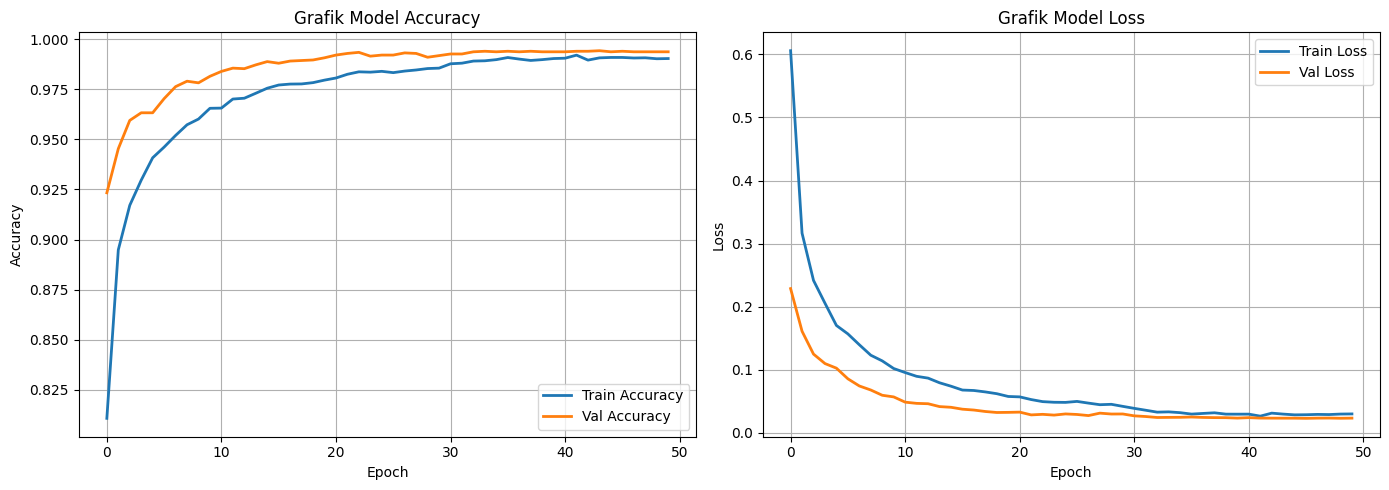

In [6]:
# ==============================================================================
# CELL 5: VISUALISASI GRAFIK ACCURACY & LOSS DARI FILE CSV
# ==============================================================================
if os.path.exists(csv_path):
    log_data = pd.read_csv(csv_path)

    plt.figure(figsize=(14, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(log_data['epoch'], log_data['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(log_data['epoch'], log_data['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Grafik Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(log_data['epoch'], log_data['loss'], label='Train Loss', linewidth=2)
    plt.plot(log_data['epoch'], log_data['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Grafik Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


[EVALUASI] Menghitung Metrik pada Data Testing...
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step

-> Akurasi Testing: 99.35%

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

     battery       1.00      1.00      1.00       227
  biological       1.00      0.99      1.00       210
   cardboard       0.99      0.99      0.99       423
     clothes       1.00      1.00      1.00       568
       glass       1.00      0.98      0.99       521
       metal       0.98      1.00      0.99       279
       paper       0.98      1.00      0.99       401
     plastic       0.99      0.99      0.99       479
       shoes       1.00      1.00      1.00       434
       trash       0.98      0.99      0.98       136

    accuracy                           0.99      3678
   macro avg       0.99      0.99      0.99      3678
weighted avg       0.99      0.99      0.99      3678



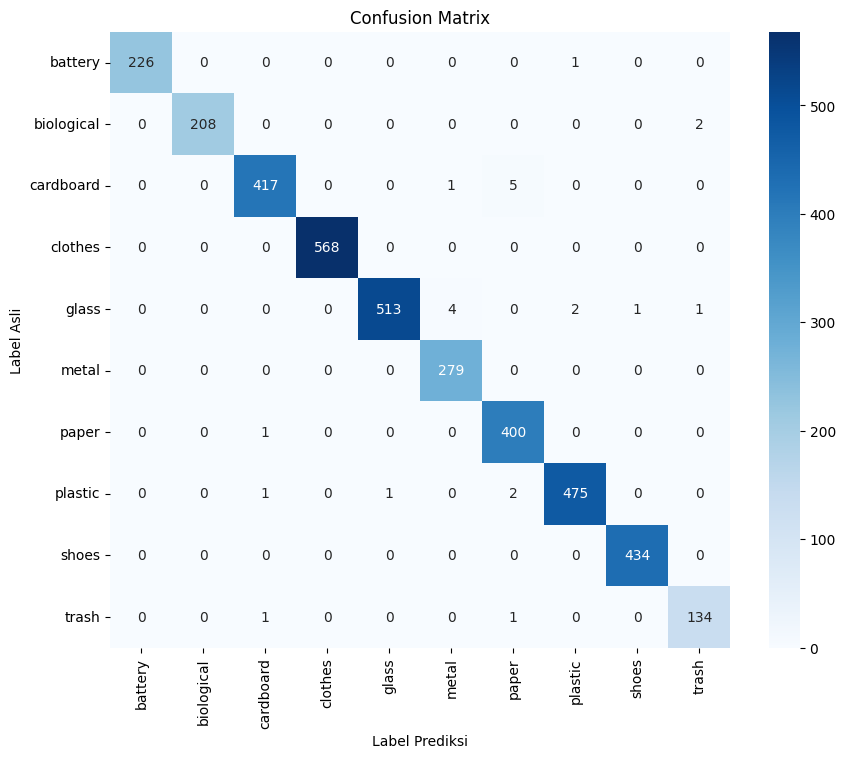

In [7]:
# ==============================================================================
# CELL 6: EVALUASI TESTING & CONFUSION MATRIX
# ==============================================================================
print("\n[EVALUASI] Menghitung Metrik pada Data Testing...")
best_model = load_model(model_path_base)

# Prediksi
test_gen.reset()
preds = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Laporan Klasifikasi
print(f"\n-> Akurasi Testing: {accuracy_score(y_true, y_pred)*100:.2f}%\n")
print("[CLASSIFICATION REPORT]")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.show()

In [11]:
# ==============================================================================
# CELL 7: KONVERSI MODEL KE ONNX (SIMPAN DI DRIVE)
# ==============================================================================
import os

print("\n[INFO] Memulai proses konversi model ResNet50 ke format ONNX...")

# Pastikan variabel DRIVE_MODEL_DIR sudah didefinisikan sebelumnya
onnx_output_path = os.path.join(DRIVE_MODEL_DIR, "resnet50_garbage_ecoplan.onnx")
temp_saved_model_dir = os.path.join(DRIVE_MODEL_DIR, "temp_resnet50_saved_model")

# 1. Ekspor model Keras 3 ke format TensorFlow SavedModel
print("[INFO] Mengekspor model ke format SavedModel sementara...")
best_model.export(temp_saved_model_dir)

print("\n[INFO] Mengonversi SavedModel ke ONNX melalui CLI...")


[INFO] Memulai proses konversi model ResNet50 ke format ONNX...
[INFO] Mengekspor model ke format SavedModel sementara...
Saved artifact at '/content/drive/MyDrive/Skripsi_EcoPlan/models/temp_resnet50_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138704495248016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495252240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495248400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495248208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495247824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495252048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495252432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138704495256848: TensorSpec(shape=(), dtype=

In [12]:
!python -m tf2onnx.convert --saved-model "{temp_saved_model_dir}" --output "{onnx_output_path}" --opset 13

I0000 00:00:1789206168.928226   78258 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9541 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-09-12 09:42:48,929 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-09-12 09:42:51,003 - INFO - Signatures found in model: [serve,serving_default].
2026-09-12 09:42:51,003 - WARNING - '--signature_def' not specified, using first signature: serve
2026-09-12 09:42:51,004 - INFO - Output names: ['output_0']
I0000 00:00:1789206171.019929   78258 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1789206171.020134   78258 single_machine.cc:376] Starting new session
I0000 00:00:1789206171.028611   78258 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9541 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:17892